# Training a U-Net for Microcalcification Segmentation

This notebook trains a simple U-Net on the INbreast dataset (COCO annotations) to segment microcalcifications in mammograms using the `medical_image` framework.

In [1]:
!pip install medical-image-std scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.2/109.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Asma_Inbreast_dataset.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'Successfully unzipped {zip_path} to {extract_path}')

Successfully unzipped /content/drive/MyDrive/Asma_Inbreast_dataset.zip to /content/


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

from medical_image.datasets.inbreast import INbreastDataset

## 1. Load Dataset

In [5]:
IMG_SIZE = (256, 256)

# Just point to the root directory — the dataset auto-detects COCO annotations
dataset = INbreastDataset(
    root_dir="/content/output_dataset/",
    target_size=IMG_SIZE,
)

print(f"Dataset size: {len(dataset)} samples")
print(f"Mode: {dataset._mode}")
# Train/validation split (80/20)
n_train = int(0.8 * len(dataset))
n_val = len(dataset) - n_train
train_ds, val_ds = random_split(dataset, [n_train, n_val])

print(f"Total: {len(dataset)}, Train: {len(train_ds)}, Val: {len(val_ds)}")

Dataset size: 50 samples
Mode: coco
Total: 50, Train: 40, Val: 10


In [6]:
BATCH_SIZE = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Verify
batch = next(iter(train_loader))
print(f"Image batch: {batch['image'].shape}")
print(f"Mask batch:  {batch['mask'].shape}")

Image batch: torch.Size([2, 1, 256, 256])
Mask batch:  torch.Size([2, 1, 256, 256])


## 2. U-Net Model

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=(32, 64, 128, 256)):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)

        for f in features:
            self.downs.append(DoubleConv(in_channels, f))
            in_channels = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(f * 2, f))

        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip = skip_connections[i // 2]
            if x.shape != skip.shape:
                x = F.pad(x, [
                    0, skip.shape[3] - x.shape[3],
                    0, skip.shape[2] - x.shape[2],
                ])
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i + 1](x)

        return self.final(x)

## 3. Loss and Metrics

In [8]:
class DiceBCELoss(nn.Module):
    """Combined Dice + BCE loss for class-imbalanced segmentation."""

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        pred_sig = torch.sigmoid(pred)
        intersection = (pred_sig.view(-1) * target.view(-1)).sum()
        dice_loss = 1 - (2.0 * intersection + self.smooth) / (
            pred_sig.view(-1).sum() + target.view(-1).sum() + self.smooth
        )
        return bce_loss + dice_loss


def dice_score(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum()
    return (2.0 * intersection) / (pred.sum() + target.sum() + 1e-8)

## 4. Training

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = UNet(in_channels=1, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = DiceBCELoss()

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Parameters: 7,765,409


In [10]:
NUM_EPOCHS = 20

train_losses = []
val_dices = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        pred = model(images)
        loss = criterion(pred, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    total_dice = 0.0
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(device)
            masks = batch["mask"].to(device)
            pred = model(images)
            total_dice += dice_score(pred, masks).item()

    avg_dice = total_dice / max(len(val_loader), 1)
    val_dices.append(avg_dice)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | Val Dice: {avg_dice:.4f}")

Epoch 01/20 | Loss: 1.4813 | Val Dice: 0.0000
Epoch 02/20 | Loss: 1.3597 | Val Dice: 0.0000
Epoch 03/20 | Loss: 1.2977 | Val Dice: 0.0000
Epoch 04/20 | Loss: 1.2442 | Val Dice: 0.0000
Epoch 05/20 | Loss: 1.1982 | Val Dice: 0.0000
Epoch 06/20 | Loss: 1.1582 | Val Dice: 0.0000
Epoch 07/20 | Loss: 1.1286 | Val Dice: 0.0000
Epoch 08/20 | Loss: 1.1056 | Val Dice: 0.0000
Epoch 09/20 | Loss: 1.0824 | Val Dice: 0.0000
Epoch 10/20 | Loss: 1.0687 | Val Dice: 0.0000
Epoch 11/20 | Loss: 1.0557 | Val Dice: 0.0000
Epoch 12/20 | Loss: 1.0460 | Val Dice: 0.0000
Epoch 13/20 | Loss: 1.0389 | Val Dice: 0.0000
Epoch 14/20 | Loss: 1.0341 | Val Dice: 0.0000
Epoch 15/20 | Loss: 1.0315 | Val Dice: 0.0000
Epoch 16/20 | Loss: 1.0257 | Val Dice: 0.0000
Epoch 17/20 | Loss: 1.0221 | Val Dice: 0.0000
Epoch 18/20 | Loss: 1.0195 | Val Dice: 0.0000
Epoch 19/20 | Loss: 1.0163 | Val Dice: 0.0000
Epoch 20/20 | Loss: 1.0171 | Val Dice: 0.0000


## 5. Training Curves

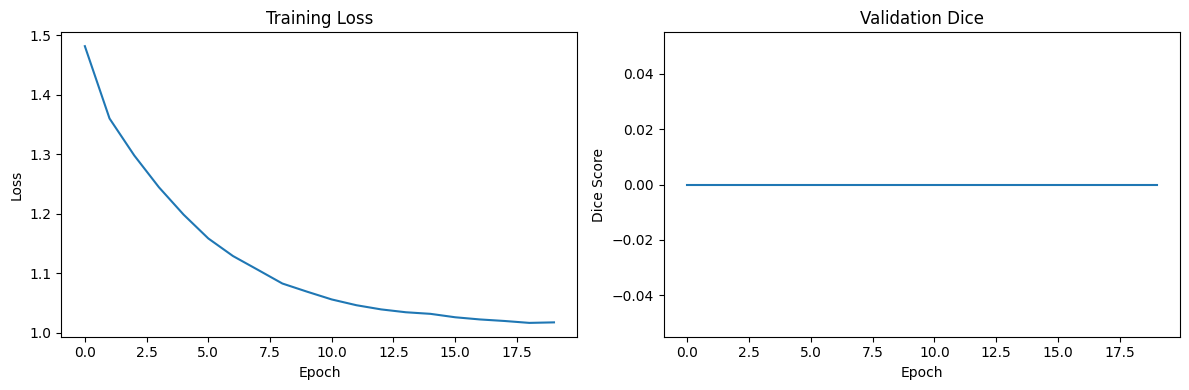

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss")
ax2.plot(val_dices)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Dice Score")
ax2.set_title("Validation Dice")
plt.tight_layout()
plt.show()

## 6. Visualize Predictions

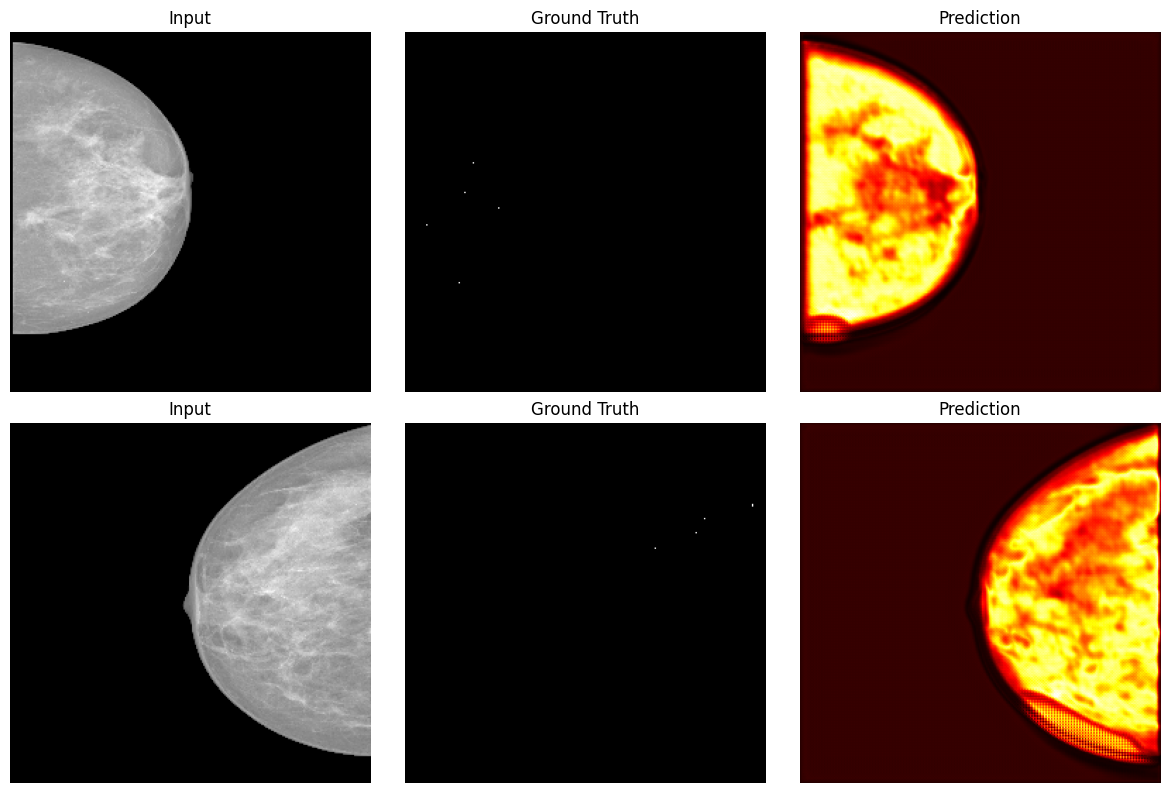

In [12]:
model.eval()
batch = next(iter(val_loader))
images = batch["image"].to(device)
masks = batch["mask"].to(device)

with torch.no_grad():
    preds = torch.sigmoid(model(images))

n = min(4, images.shape[0])
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1:
    axes = axes[None, :]

for i in range(n):
    axes[i, 0].imshow(images[i, 0].cpu().numpy(), cmap="gray")
    axes[i, 0].set_title("Input")
    axes[i, 1].imshow(masks[i, 0].cpu().numpy(), cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 2].imshow(preds[i, 0].cpu().numpy(), cmap="hot")
    axes[i, 2].set_title("Prediction")

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Save Model

In [13]:
torch.save(model.state_dict(), "unet_mc_segmentation.pth")
print("Model saved to unet_mc_segmentation.pth")

Model saved to unet_mc_segmentation.pth
